In [2]:
print(123) # test part

123


# 项目结构：
1. 项目研究方向：<br>
本项目主要利用淘宝用户行为数据集，进行客户对不同商品的兴趣程度、点击率、购买率进行分析和研究，探寻不同种类的商品对客户的吸引程度，为电商平台提高用户购买率提出建议。<br>  
2. 数据来源和数据质量：<br>
数据集来源于阿里天池数据库，包含接近1亿条信息，主要包含用户id，商品id，商品类别id，以及时间戳。数据主要是2017~18年的数据，不具有很高的时效性，但完整度和一致性很高，不具有过多空缺值和异常值。根据以上数据维度，可以分析点击率与收藏购买的关系，或者分析哪类商品最受欢迎等<br>
3. 研究过程建立：<br>
本次研究项目主要使用python以及sql的统计研究软件，标准化研究过程为：数据收集→预处理→探索性分析（EDA）→建模→可视化→结论输出。<br>
4. 项目框架：<br>
项目目前主要包括抽样、清洗数据、计算每天浏览量、计算每小时浏览量

用python连接mysql并且测试

In [2]:
import pymysql

conn = pymysql.connect(host =  'localhost',
                      user = 'root',
                      password = '20051108',
                      db = 'demo',
                          port = 3306,
                          charset = 'utf8'
                      )

def sql_do(query):
    cursor = conn.cursor()
    cursor.execute(query)
    result = cursor.fetchall()
    cursor.close()
    return result

In [4]:
# test the connection
result = sql_do("SELECT 1")
print (result);

((1,),)


清洗数据，转换时间戳为可读时间，抽样

In [ ]:
# 添加新列 readable_time，类型为 DATETIME
sql_do("ALTER TABLE sampled_data ADD COLUMN readable_time DATETIME;")

#  转换时间戳为可读时间并且保存
sql_do("UPDATE sampled_data SET readable_time = FROM_UNIXTIME('3');")

抽样部分之前在python进行的抽样

In [ ]:
sample_size = 5000 
sampled_df = df.sample(n=sample_size, random_state=42) 

# 保存为新的CSV文件
sampled_df.to_csv('sampled_data.csv', index=False)

按照每天对浏览量进行分类

In [3]:
data = sql_do("SELECT DATE(readable_time1) AS date, COUNT(*) AS record_count FROM sampled_data GROUP BY DATE(readable_time1) ORDER BY date")
print(data)

((None, 18213845), (datetime.date(2017, 11, 24), 61), (datetime.date(2017, 11, 25), 498), (datetime.date(2017, 11, 26), 566), (datetime.date(2017, 11, 27), 508), (datetime.date(2017, 11, 28), 499), (datetime.date(2017, 11, 29), 507), (datetime.date(2017, 11, 30), 515), (datetime.date(2017, 12, 1), 536), (datetime.date(2017, 12, 2), 701), (datetime.date(2017, 12, 3), 609))


In [4]:
import pandas as pd

df = pd.DataFrame(data, columns = ['times', 'counts'])

In [7]:
# 1. 添加新列 readable_time，类型为 DATETIME

print (df)


sql_do("UPDATE sampled_data SET readable_time = FROM_UNIXTIME(timestamp_column);")# 2. 用 FROM_UNIXTIME 把原有的 timestamp 字段（假设叫 timestamp_column）转换为 DATETIME 并写入 readable_timesql_do("ALTER TABLE sampled_data ADD COLUMN readable_time DATETIME;")print (df)

         times  counts
1   2017-11-24      61
2   2017-11-25     498
3   2017-11-26     566
4   2017-11-27     508
5   2017-11-28     499
6   2017-11-29     507
7   2017-11-30     515
8   2017-12-01     536
9   2017-12-02     701
10  2017-12-03     609


         times  counts
2   2017-11-25     498
3   2017-11-26     566
4   2017-11-27     508
5   2017-11-28     499
6   2017-11-29     507
7   2017-11-30     515
8   2017-12-01     536
9   2017-12-02     701
10  2017-12-03     609


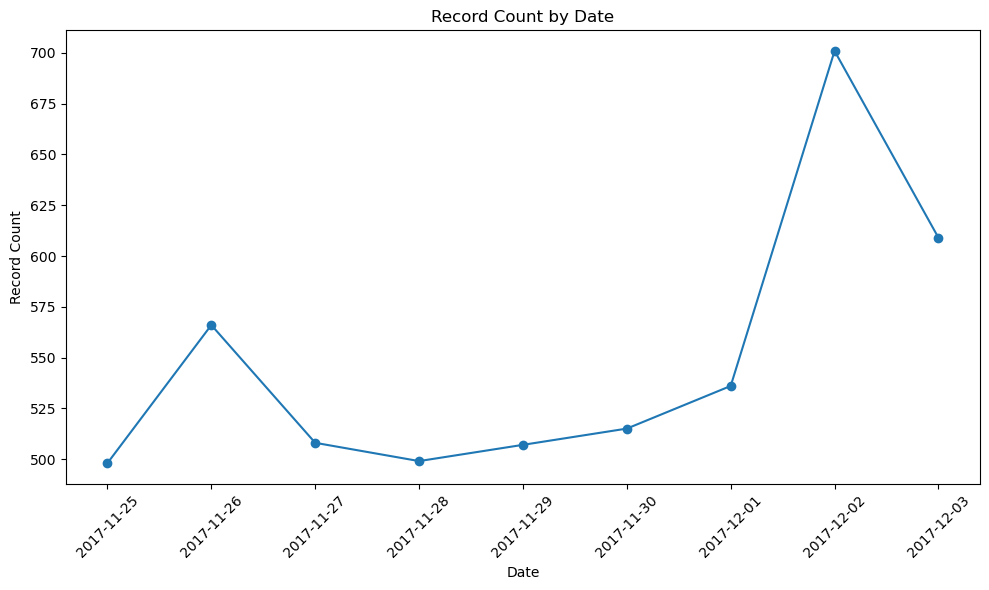

In [10]:
import matplotlib.pyplot as plt

# 假设 df 已经存在，并且 'times' 列为日期字符串

# 删除 times 为 '2017-11-24' 的行
df = df[df['times'] != '2017-11-24']
print(df)

df['times'] = df['times'].astype(str)
plt.figure(figsize=(10, 6))
plt.plot(df['times'], df['counts'], marker='o')  # 折线图
plt.xlabel('Date')
plt.ylabel('Record Count')
plt.title('Record Count by Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

根据上图可见，在周末的用户量比工作日明显增多。说明周末是主要淘宝用户的主要参观浏览时间点。

查询每小时有多少流量

In [ ]:
# 使用 sql_do 查询每小时的记录数
query = """
SELECT   
    HOUR(readable_time1) AS hour,  
    COUNT(*) AS record_count                       
FROM 
    sampled_data
GROUP BY 
    HOUR(readable_time1)
ORDER BY 
    hour
"""
hour_data = sql_do(query)
import pandas as pd
df_hour = pd.DataFrame(hour_data, columns=['hour', 'record_count'])

In [13]:
df_hour = df_hour.drop(index=0)  # 删除第一行
print(df_hour)

    hour  record_count
1    0.0           175
2    1.0           231
3    2.0           237
4    3.0           228
5    4.0           238
6    5.0           261
7    6.0           288
8    7.0           255
9    8.0           247
10   9.0           259
11  10.0           245
12  11.0           300
13  12.0           359
14  13.0           388
15  14.0           428
16  15.0           296
17  16.0           164
18  17.0            69
19  18.0            58
20  19.0            32
21  20.0            26
22  21.0            31
23  22.0            68
24  23.0           117


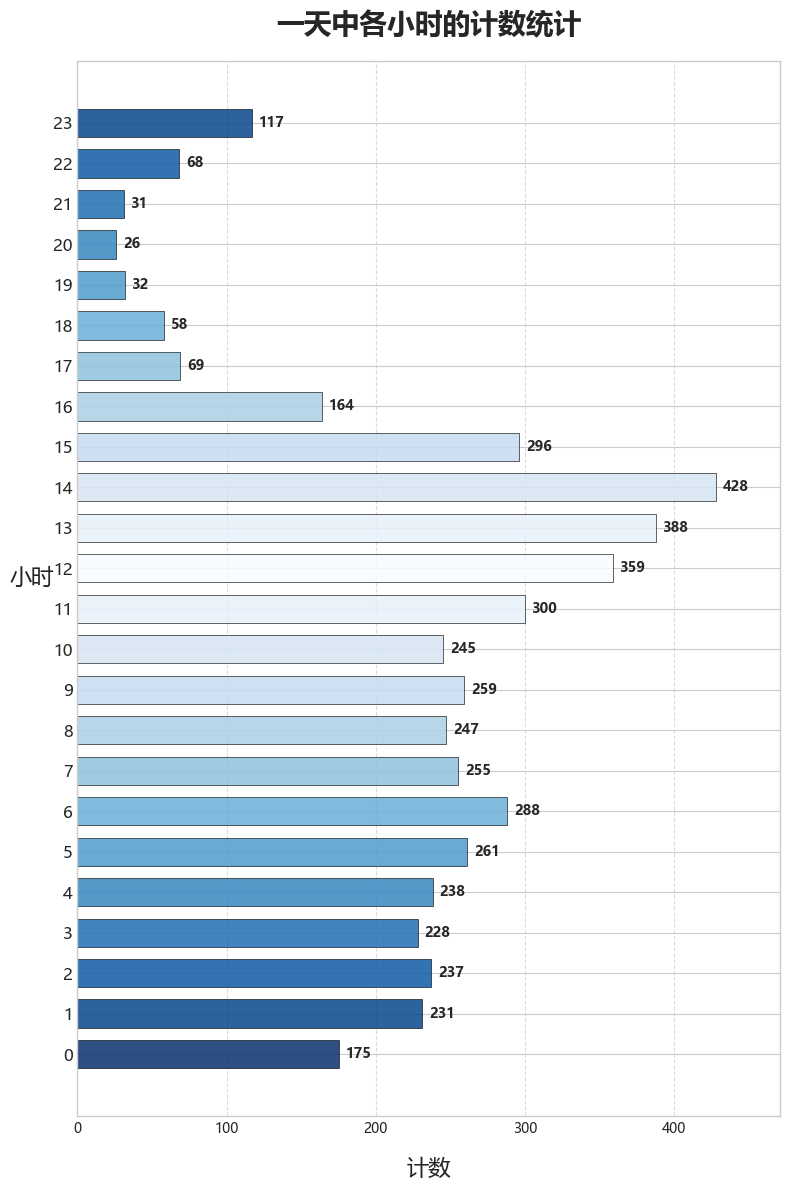

In [15]:
plt.rcParams["font.family"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False
hours = df_hour['hour'].astype(int).tolist()
counts = df_hour['record_count'].astype(int).tolist()

# 计算各小时与12点的距离（用于颜色映射）
def distance_to_12(hour):
    return min(abs(hour - 12), 24 - abs(hour - 12))
distances = [distance_to_12(h) for h in hours]
max_distance = max(distances) if distances else 1

# 颜色映射：越接近12点颜色越浅（蓝白渐变）
color_indices = [d / max_distance for d in distances]
colors = [plt.cm.Blues(idx) for idx in color_indices]

# 创建竖版图形（高度大于宽度）
fig, ax = plt.subplots(figsize=(8, 12))

# 绘制水平柱状图
bars = ax.barh(hours, counts, height=0.7, color=colors, edgecolor='black',
               linewidth=0.5, alpha=0.85)

# 添加标题和标签
ax.set_title('一天中各小时的计数统计', fontsize=20, pad=20, fontweight='bold')
ax.set_xlabel('计数', fontsize=16, labelpad=15)
ax.set_ylabel('小时', fontsize=16, labelpad=15, rotation=0)

# 设置y轴刻度和标签
ax.set_yticks(hours)
ax.set_yticklabels(hours, fontsize=12)

# 设置x轴范围
ax.set_xlim(0, max(counts) * 1.1 if counts else 1)

# 添加网格线
ax.grid(axis='x', linestyle='--', alpha=0.7)

# 添加数值标签
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{int(width)}',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0),
                textcoords="offset points",
                ha='left', va='center',
                fontsize=10,
                fontweight='bold')

# 美化图表
plt.tight_layout()
plt.style.use('seaborn-v0_8-whitegrid')

plt.show()

根据图中可以发现，在2017-11-24至2017-12-03之间，淘宝的用户主要在中午和上午进行浏览，而晚上的浏览人数则大幅度减少。这可能是因为早期淘宝还没有在晚上进行各种促销，以及白天选择购物的人数较多造成的。凌晨大量用户可能是因为当时有机器人进行软件测试，但是这个数据分布确实比较不合常理。